# Experiment Analysis — Health Claims Fact-Checker

This notebook analyses all experiment results (E1–E11) across RAG and agent pipelines.

**Sections:**
1. Setup & data loading
2. Overall accuracy comparison
3. Per-class precision / recall / F1
4. Confusion matrices
5. Cost & latency analysis
6. Error analysis (coverage gap vs reasoning error)
7. Simple vs complex claims (RAG vs agents)
8. Head-to-head: which claims do agents get right that RAG misses?
9. Statistical significance (McNemar's test)

In [2]:
# Setup
import json, os, sys
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results" / "experiments"
CLAIMS_PATH = PROJECT_ROOT / "data" / "test_claims.json"

# Load all available experiment results
experiments = {}
for f in sorted(RESULTS_DIR.glob("E*.json")):
    with open(f) as fh:
        data = json.load(fh)
    experiments[f.stem] = data

print(f"Loaded {len(experiments)} experiments: {', '.join(experiments.keys())}")

# Load test claims with ground truth
with open(CLAIMS_PATH) as fh:
    test_claims = json.load(fh)
claims_lookup = {c["claim"]: c for c in test_claims}
print(f"Test claims: {len(test_claims)}")

Loaded 9 experiments: E1, E11, E2, E3, E4, E5, E6, E7, E8
Test claims: 300


In [3]:
# Build a unified DataFrame of all results
VERDICTS = ["SUPPORTED", "UNSUPPORTED", "INSUFFICIENT_EVIDENCE"]

rows = []
for exp_id, data in experiments.items():
    config = data.get("config", {})
    for r in data.get("results", []):
        is_error = bool(r.get("error")) or r.get("verdict") == "ERROR"
        rows.append({
            "experiment": exp_id,
            "name": config.get("name", exp_id),
            "chunking": config.get("chunking_strategy", ""),
            "retrieval": config.get("retrieval_method", ""),
            "agent": config.get("agent_architecture", ""),
            "model": config.get("model", ""),
            "claim": r.get("claim", ""),
            "predicted": r.get("verdict", ""),
            "expected": r.get("expected_verdict", ""),
            "correct": bool(r.get("correct")) and not is_error,
            "is_error": is_error,
            "explanation": r.get("explanation", ""),
            "latency": r.get("metadata", {}).get("latency_seconds", None),
            "cost": r.get("metadata", {}).get("estimated_cost_usd", None),
            "tokens": r.get("metadata", {}).get("total_tokens", None),
        })

df = pd.DataFrame(rows)
df_valid = df[~df["is_error"]].copy()
print(f"Total rows: {len(df)} | Valid (no errors): {len(df_valid)}")
print(f"\nError counts per experiment:")
print(df.groupby("experiment")["is_error"].sum().to_string())

Total rows: 2700 | Valid (no errors): 2644

Error counts per experiment:
experiment
E1      1
E11    37
E2      0
E3      0
E4      0
E5      0
E6      0
E7     18
E8      0


## 2. Overall Accuracy Comparison

In [4]:
# Overall accuracy table
acc_rows = []
for exp_id in sorted(experiments.keys(), key=lambda x: int(x[1:])):
    sub = df_valid[df_valid["experiment"] == exp_id]
    if len(sub) == 0:
        continue
    total = len(sub)
    correct = sub["correct"].sum()
    errors = df[(df["experiment"] == exp_id) & df["is_error"]].shape[0]
    acc_rows.append({
        "Experiment": exp_id,
        "Name": sub["name"].iloc[0],
        "Chunking": sub["chunking"].iloc[0],
        "Retrieval": sub["retrieval"].iloc[0],
        "Agent": sub["agent"].iloc[0],
        "Model": sub["model"].iloc[0][:20],
        "Valid Claims": total,
        "Correct": correct,
        "Errors": errors,
        "Accuracy (%)": round(correct / total * 100, 1),
    })

acc_df = pd.DataFrame(acc_rows)
display(acc_df.style.background_gradient(subset=["Accuracy (%)"], cmap="RdYlGn", vmin=30, vmax=90))

,Experiment,Name,Chunking,Retrieval,Agent,Model,Valid Claims,Correct,Errors,Accuracy (%)
0,E1,Fixed chunking + naive RAG,fixed,naive,single_pass,claude-sonnet-4-2025,299,239,1,79.900000
1,E2,Section-aware chunking + naive RAG,section_aware,naive,single_pass,claude-sonnet-4-2025,300,232,0,77.300000
2,E3,Semantic chunking + naive RAG,semantic,naive,single_pass,claude-sonnet-4-2025,300,229,0,76.300000
3,E4,Recursive chunking + naive RAG,recursive,naive,single_pass,claude-sonnet-4-2025,300,246,0,82.000000
4,E5,Best chunking + hybrid RAG,recursive,hybrid,single_pass,claude-sonnet-4-2025,300,237,0,79.000000
5,E6,Best chunking + hybrid reranked RAG,recursive,hybrid_reranked,single_pass,claude-sonnet-4-2025,300,244,0,81.300000
6,E7,Best RAG + Strands agents,recursive,naive,strands_multi,claude-sonnet-4-2025,282,196,18,69.500000
7,E8,Best RAG + LangGraph agents,recursive,naive,langgraph_multi,claude-sonnet-4-2025,300,198,0,66.000000
8,E11,Llama 3.1 8B baseline,recursive,hybrid_reranked,single_pass,llama3.1:8b,263,171,37,65.000000


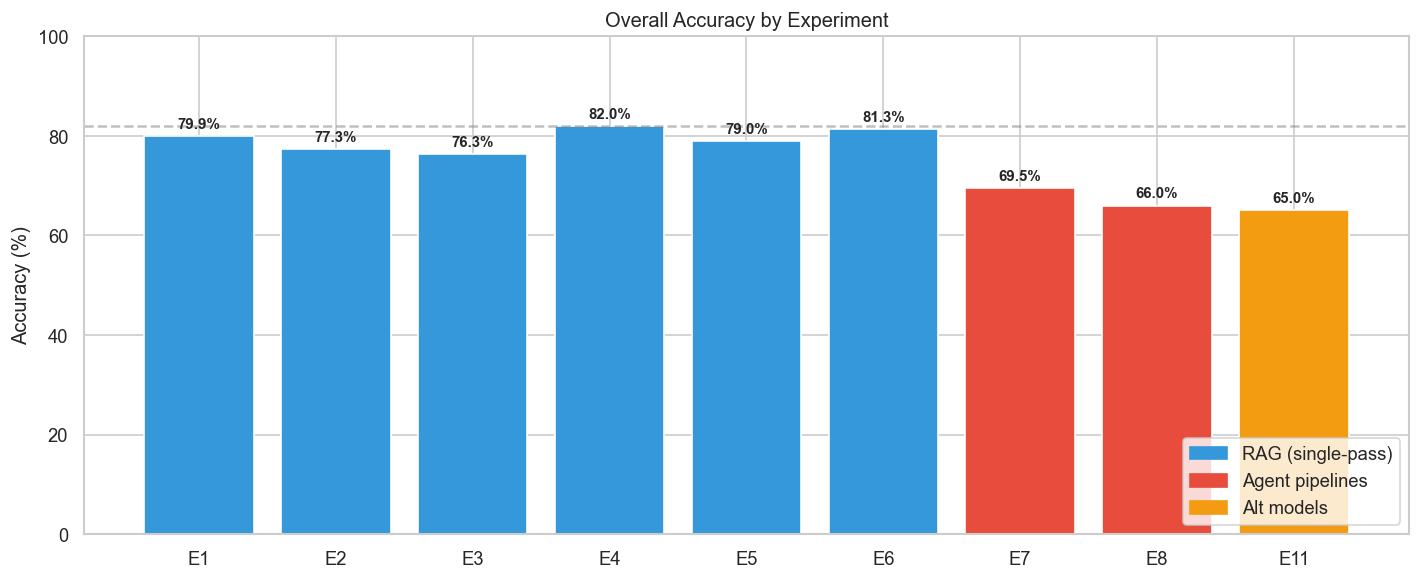

In [5]:
# Accuracy bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = []
for _, row in acc_df.iterrows():
    if row["Agent"] in ("strands_multi", "langgraph_multi", "strands_rerouting"):
        colors.append("#e74c3c")  # red for agents
    elif "llama" in str(row["Model"]).lower() or "gpt" in str(row["Model"]).lower():
        colors.append("#f39c12")  # orange for alt models
    else:
        colors.append("#3498db")  # blue for RAG

bars = ax.bar(acc_df["Experiment"], acc_df["Accuracy (%)"], color=colors, edgecolor="white")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Overall Accuracy by Experiment")
ax.set_ylim(0, 100)
ax.axhline(y=acc_df[acc_df["Experiment"] == "E4"]["Accuracy (%)"].values[0] if "E4" in acc_df["Experiment"].values else 82,
           color="gray", linestyle="--", alpha=0.5, label="Best RAG (E4)")

for bar, acc in zip(bars, acc_df["Accuracy (%)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{acc}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#3498db", label="RAG (single-pass)"),
    Patch(color="#e74c3c", label="Agent pipelines"),
    Patch(color="#f39c12", label="Alt models"),
], loc="lower right")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "accuracy_comparison.png", bbox_inches="tight")
plt.show()

## 3. Per-Class Precision / Recall / F1

In [6]:
# Per-class metrics for each experiment
class_rows = []
for exp_id in sorted(experiments.keys(), key=lambda x: int(x[1:])):
    sub = df_valid[(df_valid["experiment"] == exp_id) & df_valid["predicted"].isin(VERDICTS) & df_valid["expected"].isin(VERDICTS)]
    if len(sub) == 0:
        continue
    report = classification_report(sub["expected"], sub["predicted"], labels=VERDICTS, output_dict=True, zero_division=0)
    for v in VERDICTS:
        class_rows.append({
            "Experiment": exp_id,
            "Verdict": v,
            "Precision": round(report[v]["precision"] * 100, 1),
            "Recall": round(report[v]["recall"] * 100, 1),
            "F1": round(report[v]["f1-score"] * 100, 1),
            "Support": report[v]["support"],
        })
    class_rows.append({
        "Experiment": exp_id,
        "Verdict": "macro avg",
        "Precision": round(report["macro avg"]["precision"] * 100, 1),
        "Recall": round(report["macro avg"]["recall"] * 100, 1),
        "F1": round(report["macro avg"]["f1-score"] * 100, 1),
        "Support": report["macro avg"]["support"],
    })

class_df = pd.DataFrame(class_rows)
# Show as pivot for readability
for metric in ["F1"]:
    pivot = class_df.pivot(index="Experiment", columns="Verdict", values=metric)
    pivot = pivot[["SUPPORTED", "UNSUPPORTED", "INSUFFICIENT_EVIDENCE", "macro avg"]]
    print(f"\n{metric} Score (%) by Experiment and Verdict Class:")
    display(pivot.style.background_gradient(cmap="RdYlGn", vmin=20, vmax=90))


F1 Score (%) by Experiment and Verdict Class:


Verdict,SUPPORTED,UNSUPPORTED,INSUFFICIENT_EVIDENCE,macro avg
Experiment,,,,
E1,82.900000,82.800000,74.300000,80.000000
E11,67.500000,62.200000,65.600000,65.100000
E2,82.100000,79.600000,70.800000,77.500000
E3,78.900000,80.200000,70.900000,76.700000
E4,86.700000,82.600000,76.500000,81.900000
E5,84.400000,81.200000,72.000000,79.200000
E6,86.400000,82.400000,75.200000,81.400000
E7,67.100000,77.800000,62.400000,69.100000
E8,64.500000,70.900000,61.700000,65.700000


## 4. Confusion Matrices

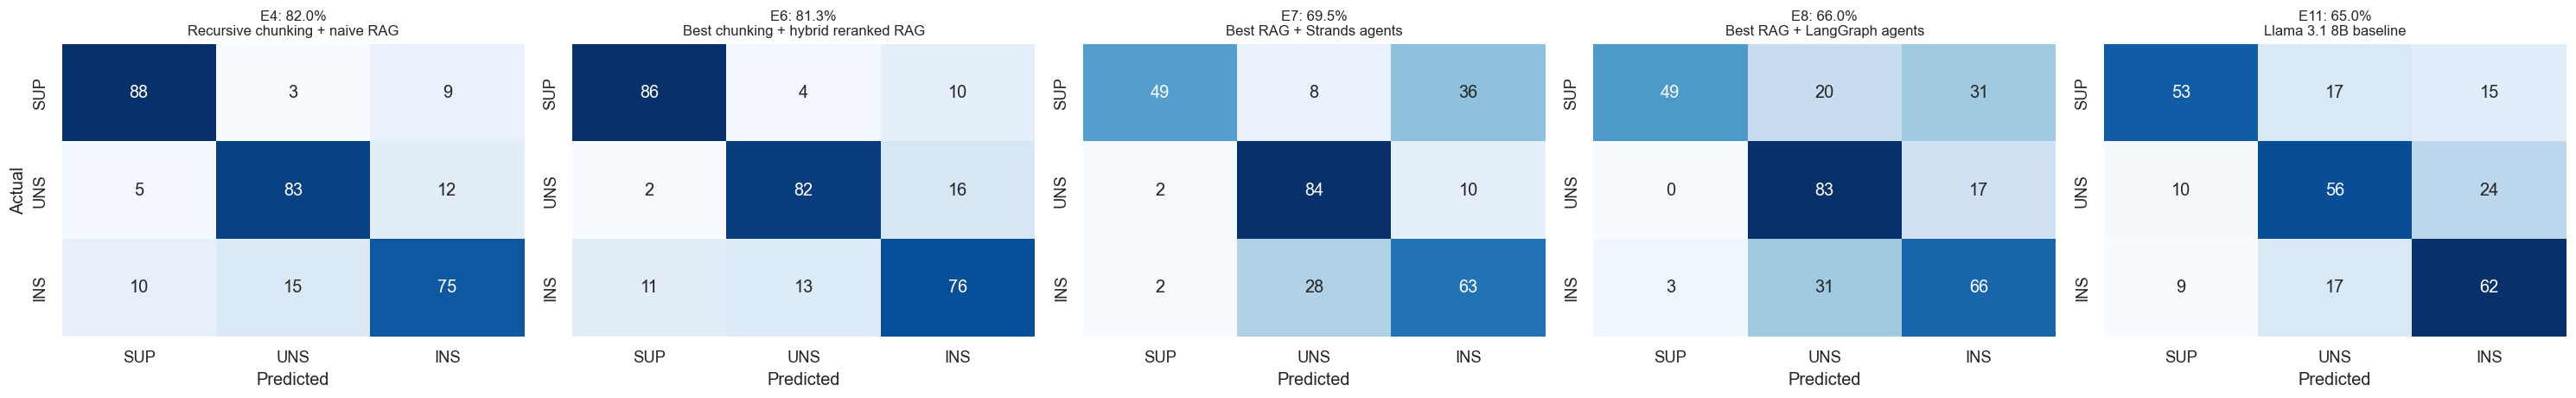

In [7]:
# Confusion matrices for key experiments
key_exps = [e for e in ["E4", "E6", "E7", "E8", "E11"] if e in experiments]
short_labels = ["SUP", "UNS", "INS"]

fig, axes = plt.subplots(1, len(key_exps), figsize=(5 * len(key_exps), 4))
if len(key_exps) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, key_exps):
    sub = df_valid[(df_valid["experiment"] == exp_id) & df_valid["predicted"].isin(VERDICTS) & df_valid["expected"].isin(VERDICTS)]
    if len(sub) == 0:
        continue
    cm = confusion_matrix(sub["expected"], sub["predicted"], labels=VERDICTS)
    # Normalize by row (recall)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=short_labels,
                yticklabels=short_labels, ax=ax, cbar=False)
    name = df_valid[df_valid["experiment"] == exp_id]["name"].iloc[0]
    acc = sub["correct"].mean() * 100
    ax.set_title(f"{exp_id}: {acc:.1f}%\n{name}", fontsize=10)
    ax.set_ylabel("Actual" if ax == axes[0] else "")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "confusion_matrices.png", bbox_inches="tight")
plt.show()

## 5. Cost & Latency Analysis

In [8]:
# Cost and latency summary
cost_rows = []
for exp_id in sorted(experiments.keys(), key=lambda x: int(x[1:])):
    sub = df_valid[df_valid["experiment"] == exp_id]
    if len(sub) == 0:
        continue
    latencies = sub["latency"].dropna()
    costs = sub["cost"].dropna()
    acc = sub["correct"].mean() * 100
    cost_rows.append({
        "Experiment": exp_id,
        "Accuracy (%)": round(acc, 1),
        "Avg Latency (s)": round(latencies.mean(), 1) if len(latencies) else None,
        "Median Latency (s)": round(latencies.median(), 1) if len(latencies) else None,
        "Total Cost ($)": round(costs.sum(), 4) if len(costs) else None,
        "Avg Cost/Claim ($)": round(costs.mean(), 5) if len(costs) else None,
    })

cost_df = pd.DataFrame(cost_rows)
display(cost_df)

,Experiment,Accuracy (%),Avg Latency (s),Median Latency (s),Total Cost ($),Avg Cost/Claim ($)
0,E1,79.9,8.5,5.0,3.6308,0.01214
1,E2,77.3,8.3,4.8,3.3563,0.01119
2,E3,76.3,9.1,5.1,2.6937,0.00898
3,E4,82.0,8.4,5.1,3.4611,0.01154
4,E5,79.0,6.1,5.8,3.6044,0.01201
5,E6,81.3,6.0,6.0,3.7161,0.01239
6,E7,69.5,209.5,68.1,1.2810,0.00454
7,E8,66.0,55.1,32.1,0.8634,0.00288
8,E11,65.0,134.5,118.0,3.2210,0.01225


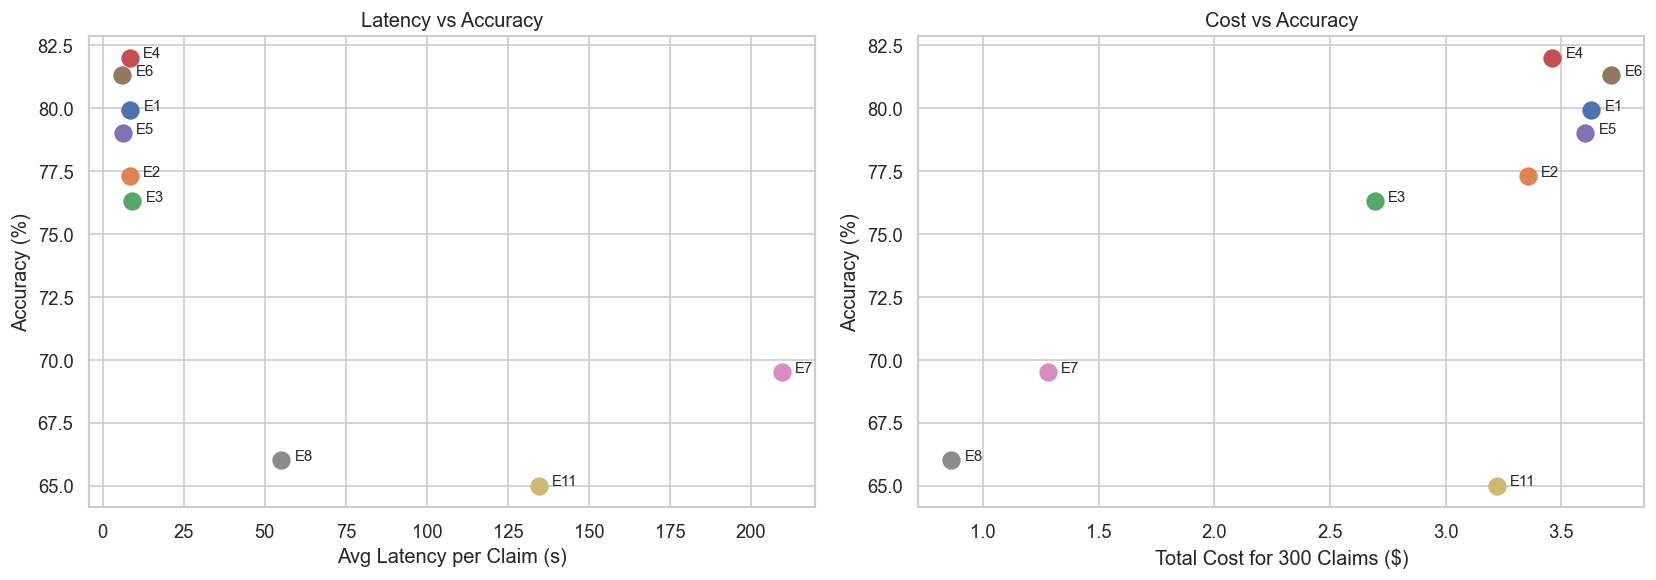

In [9]:
# Cost vs Accuracy scatter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: avg latency vs accuracy
for _, row in cost_df.iterrows():
    if row["Avg Latency (s)"] is None:
        continue
    ax1.scatter(row["Avg Latency (s)"], row["Accuracy (%)"], s=100, zorder=5)
    ax1.annotate(row["Experiment"], (row["Avg Latency (s)"], row["Accuracy (%)"]),
                 textcoords="offset points", xytext=(8, 0), fontsize=9)
ax1.set_xlabel("Avg Latency per Claim (s)")
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Latency vs Accuracy")

# Scatter: total cost vs accuracy
for _, row in cost_df.iterrows():
    if row["Total Cost ($)"] is None:
        continue
    ax2.scatter(row["Total Cost ($)"], row["Accuracy (%)"], s=100, zorder=5)
    ax2.annotate(row["Experiment"], (row["Total Cost ($)"], row["Accuracy (%)"]),
                 textcoords="offset points", xytext=(8, 0), fontsize=9)
ax2.set_xlabel("Total Cost for 300 Claims ($)")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Cost vs Accuracy")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "cost_latency_analysis.png", bbox_inches="tight")
plt.show()

## 6. Error Analysis — Coverage Gap vs Reasoning Error

Using SciFact's `evidence_doc_id` ground truth: if the correct evidence document was in the corpus and retrieved, but the model still got the verdict wrong, that's a **reasoning error**. If the correct document wasn't retrieved (or doesn't exist in corpus), that's a **coverage gap**.

In [10]:
# Build lookup: which claims have gold evidence docs in corpus?
with open(CLAIMS_PATH) as f:
    claims_data = json.load(f)

# Load corpus doc IDs
corpus_path = PROJECT_ROOT / "data" / "corpus.json"
with open(corpus_path) as f:
    corpus = json.load(f)
corpus_doc_ids = {str(doc.get("doc_id", doc.get("pmid", ""))) for doc in corpus}

# For each claim, check if gold evidence doc is in corpus
claim_coverage = {}
for c in claims_data:
    claim_text = c["claim"]
    gold_doc = str(c.get("evidence_doc_id", "")) if c.get("evidence_doc_id") else None
    has_gold = gold_doc is not None
    gold_in_corpus = gold_doc in corpus_doc_ids if gold_doc else False
    claim_coverage[claim_text] = {
        "has_gold_evidence": has_gold,
        "gold_in_corpus": gold_in_corpus,
        "gold_doc_id": gold_doc,
        "expected_verdict": c["expected_verdict"],
    }

# Stats
has_gold = sum(1 for v in claim_coverage.values() if v["has_gold_evidence"])
gold_in_corpus = sum(1 for v in claim_coverage.values() if v["gold_in_corpus"])
print(f"Claims with gold evidence doc: {has_gold}/{len(claim_coverage)}")
print(f"Gold doc in corpus: {gold_in_corpus}/{has_gold}")
print(f"No gold evidence (INSUFFICIENT_EVIDENCE claims): {len(claim_coverage) - has_gold}")

Claims with gold evidence doc: 200/300
Gold doc in corpus: 200/200
No gold evidence (INSUFFICIENT_EVIDENCE claims): 100



E4 — 54 errors out of 300 valid claims:
  Reasoning errors (gold doc in corpus, wrong verdict): 29
  Coverage gaps (gold doc NOT in corpus):               0
  No gold evidence (INS_EVIDENCE claims, misclassed):   25


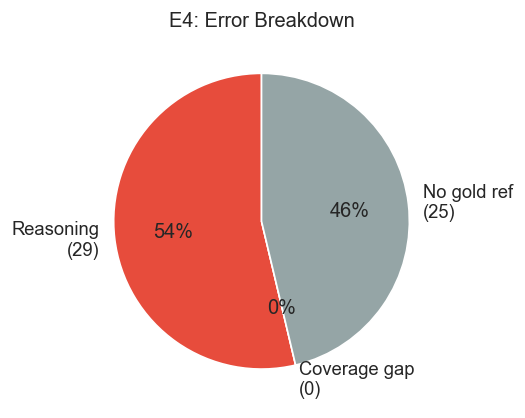


E7 — 86 errors out of 282 valid claims:
  Reasoning errors (gold doc in corpus, wrong verdict): 56
  Coverage gaps (gold doc NOT in corpus):               0
  No gold evidence (INS_EVIDENCE claims, misclassed):   30


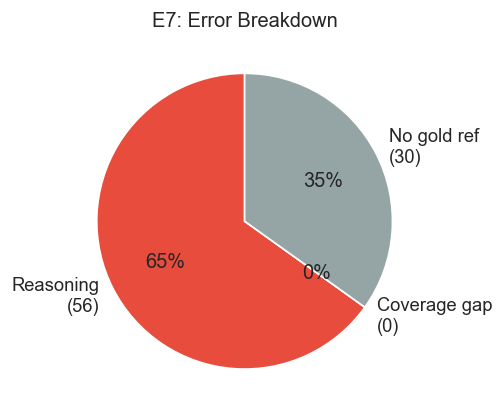


E8 — 102 errors out of 300 valid claims:
  Reasoning errors (gold doc in corpus, wrong verdict): 68
  Coverage gaps (gold doc NOT in corpus):               0
  No gold evidence (INS_EVIDENCE claims, misclassed):   34


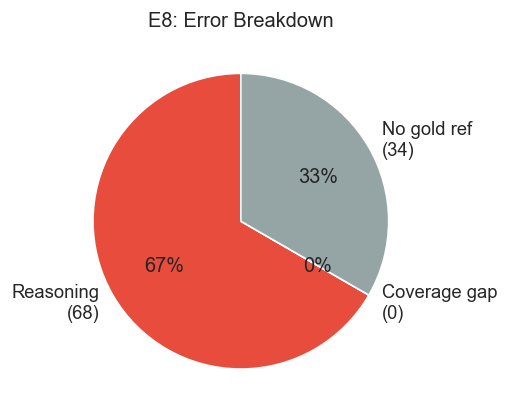

In [11]:
# Error breakdown for best RAG (E4) and agent experiments
error_analysis_exps = [e for e in ["E4", "E7", "E8"] if e in experiments]

for exp_id in error_analysis_exps:
    sub = df_valid[(df_valid["experiment"] == exp_id) & ~df_valid["correct"]]
    sub_correct = df_valid[(df_valid["experiment"] == exp_id) & df_valid["correct"]]

    reasoning_errors = 0
    coverage_gaps = 0
    no_gold = 0

    for _, row in sub.iterrows():
        info = claim_coverage.get(row["claim"], {})
        if not info.get("has_gold_evidence"):
            no_gold += 1  # INSUFFICIENT_EVIDENCE claim — no gold doc to check
        elif info.get("gold_in_corpus"):
            reasoning_errors += 1  # Gold doc exists in corpus but still got wrong
        else:
            coverage_gaps += 1  # Gold doc not in corpus

    total_errors = len(sub)
    total_valid = len(df_valid[df_valid["experiment"] == exp_id])
    print(f"\n{exp_id} — {total_errors} errors out of {total_valid} valid claims:")
    print(f"  Reasoning errors (gold doc in corpus, wrong verdict): {reasoning_errors}")
    print(f"  Coverage gaps (gold doc NOT in corpus):               {coverage_gaps}")
    print(f"  No gold evidence (INS_EVIDENCE claims, misclassed):   {no_gold}")

    # Pie chart
    if total_errors > 0:
        fig, ax = plt.subplots(figsize=(5, 4))
        sizes = [reasoning_errors, coverage_gaps, no_gold]
        labels = [f"Reasoning\n({reasoning_errors})", f"Coverage gap\n({coverage_gaps})", f"No gold ref\n({no_gold})"]
        colors_pie = ["#e74c3c", "#f39c12", "#95a5a6"]
        ax.pie(sizes, labels=labels, colors=colors_pie, autopct="%1.0f%%", startangle=90)
        ax.set_title(f"{exp_id}: Error Breakdown")
        plt.show()

## 7. Evidence-Linked vs No-Link Claims

All 300 claims have ground-truth verdict labels. The distinction here is about **evidence linkage** — whether SciFact provides a specific document ID that contains the proof.

- **Evidence-linked (200 claims)**: SUPPORTED and UNSUPPORTED claims each have an `evidence_doc_id` pointing to the exact abstract in the corpus that proves or disproves them. All 200 of these gold documents exist in our corpus. For these claims, we know the answer is retrievable — so any wrong prediction is a **reasoning error**, not a retrieval failure.

- **No-link (100 claims)**: INSUFFICIENT_EVIDENCE claims have `evidence_doc_id = null`. By definition, no specific document in the corpus addresses these claims — that's precisely *why* they're labeled INSUFFICIENT_EVIDENCE. Getting these right requires the model to recognize that tangentially related evidence doesn't actually address the specific claim.

This split helps us understand *why* pipelines fail: are they unable to find the right evidence (retrieval problem) or unable to interpret it correctly (reasoning problem)?

,Experiment,Difficulty,Claims,Accuracy (%)
0,E4,Easy (gold in corpus),200,85.5
1,E4,Hard (no gold / not in corpus),100,75.0
2,E7,Easy (gold in corpus),189,70.4
3,E7,Hard (no gold / not in corpus),93,67.7
4,E8,Easy (gold in corpus),200,66.0
5,E8,Hard (no gold / not in corpus),100,66.0


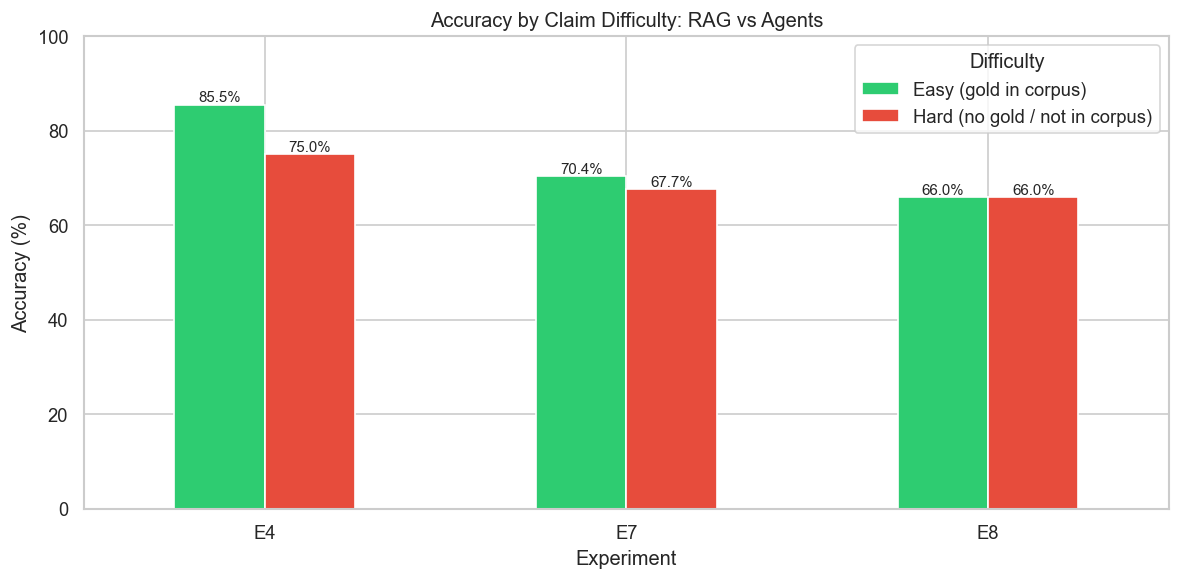

In [12]:
# Tag each claim as easy or hard
df_valid["gold_in_corpus"] = df_valid["claim"].map(
    lambda c: claim_coverage.get(c, {}).get("gold_in_corpus", False)
)
df_valid["difficulty"] = df_valid["claim"].apply(
    lambda c: "Easy (gold in corpus)" if claim_coverage.get(c, {}).get("gold_in_corpus")
    else "Hard (no gold / not in corpus)"
)

# Compare accuracy by difficulty for key experiments
compare_exps = [e for e in ["E4", "E7", "E8"] if e in experiments]
diff_rows = []
for exp_id in compare_exps:
    for diff in ["Easy (gold in corpus)", "Hard (no gold / not in corpus)"]:
        sub = df_valid[(df_valid["experiment"] == exp_id) & (df_valid["difficulty"] == diff)]
        if len(sub) == 0:
            continue
        diff_rows.append({
            "Experiment": exp_id,
            "Difficulty": diff,
            "Claims": len(sub),
            "Accuracy (%)": round(sub["correct"].mean() * 100, 1),
        })

diff_df = pd.DataFrame(diff_rows)
display(diff_df)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
pivot = diff_df.pivot(index="Experiment", columns="Difficulty", values="Accuracy (%)")
pivot.plot(kind="bar", ax=ax, rot=0, color=["#2ecc71", "#e74c3c"])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by Claim Difficulty: RAG vs Agents")
ax.set_ylim(0, 100)
ax.legend(title="Difficulty")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "easy_vs_hard_claims.png", bbox_inches="tight")
plt.show()

## 8. Head-to-Head: Claims Where Agents Beat RAG (and Vice Versa)

In [13]:
# Head-to-head: E4 (best RAG) vs E8 (LangGraph agents)
agent_exp = "E8" if "E8" in experiments else ("E7" if "E7" in experiments else None)
if agent_exp is None:
    print("No agent experiment results available yet.")
else:
    rag = df_valid[df_valid["experiment"] == "E4"][["claim", "correct", "predicted"]].rename(
        columns={"correct": "rag_correct", "predicted": "rag_pred"})
    agent = df_valid[df_valid["experiment"] == agent_exp][["claim", "correct", "predicted"]].rename(
        columns={"correct": "agent_correct", "predicted": "agent_pred"})

    h2h = rag.merge(agent, on="claim", how="inner")
    h2h["expected"] = h2h["claim"].map(lambda c: claim_coverage.get(c, {}).get("expected_verdict", ""))

    # Categories
    both_right = h2h[h2h["rag_correct"] & h2h["agent_correct"]]
    both_wrong = h2h[~h2h["rag_correct"] & ~h2h["agent_correct"]]
    rag_only = h2h[h2h["rag_correct"] & ~h2h["agent_correct"]]
    agent_only = h2h[~h2h["rag_correct"] & h2h["agent_correct"]]

    print(f"Head-to-head: E4 (RAG) vs {agent_exp} (Agent) — {len(h2h)} shared claims\n")
    print(f"  Both correct:     {len(both_right)} ({len(both_right)/len(h2h)*100:.1f}%)")
    print(f"  Both wrong:       {len(both_wrong)} ({len(both_wrong)/len(h2h)*100:.1f}%)")
    print(f"  RAG only correct: {len(rag_only)} ({len(rag_only)/len(h2h)*100:.1f}%)")
    print(f"  Agent only correct: {len(agent_only)} ({len(agent_only)/len(h2h)*100:.1f}%)")

    # Show example claims where agent beats RAG
    if len(agent_only) > 0:
        print(f"\nSample claims where {agent_exp} got right but E4 got wrong:")
        for _, row in agent_only.head(5).iterrows():
            print(f"  Claim: {row['claim'][:90]}...")
            print(f"    Expected: {row['expected']} | RAG: {row['rag_pred']} | Agent: {row['agent_pred']}")
            print()

    # Show example claims where RAG beats agent
    if len(rag_only) > 0:
        print(f"Sample claims where E4 got right but {agent_exp} got wrong:")
        for _, row in rag_only.head(5).iterrows():
            print(f"  Claim: {row['claim'][:90]}...")
            print(f"    Expected: {row['expected']} | RAG: {row['rag_pred']} | Agent: {row['agent_pred']}")
            print()

Head-to-head: E4 (RAG) vs E8 (Agent) — 300 shared claims

  Both correct:     179 (59.7%)
  Both wrong:       35 (11.7%)
  RAG only correct: 67 (22.3%)
  Agent only correct: 19 (6.3%)

Sample claims where E8 got right but E4 got wrong:
  Claim: There is no known interaction between Pioneer factor OCT3/4 and major chromatin remodeling...
    Expected: UNSUPPORTED | RAG: INSUFFICIENT_EVIDENCE | Agent: UNSUPPORTED

  Claim: The one-child policy has created a hospitable environment for female infants....
    Expected: UNSUPPORTED | RAG: INSUFFICIENT_EVIDENCE | Agent: UNSUPPORTED

  Claim: Repressing IL-18 has negative effects on atherosclerotic lesion composition and progressio...
    Expected: UNSUPPORTED | RAG: INSUFFICIENT_EVIDENCE | Agent: UNSUPPORTED

  Claim: Suboptimal nutrition is a leading cause of premature death...
    Expected: SUPPORTED | RAG: INSUFFICIENT_EVIDENCE | Agent: SUPPORTED

  Claim: Female carriers of the Apolipoprotein E4 (APOE4) allele have shorter lifetime exposu

## 9. Statistical Significance (McNemar's Test)

Tests whether the difference between two pipelines is statistically significant (not just noise).

In [14]:
from scipy.stats import chi2

def mcnemar_test(exp_a: str, exp_b: str) -> dict:
    """McNemar's test comparing two experiments on shared claims."""
    a = df_valid[df_valid["experiment"] == exp_a][["claim", "correct"]].rename(columns={"correct": "a_correct"})
    b = df_valid[df_valid["experiment"] == exp_b][["claim", "correct"]].rename(columns={"correct": "b_correct"})
    merged = a.merge(b, on="claim", how="inner")

    # Contingency: b (discordant cells)
    b_right_a_wrong = ((merged["b_correct"]) & (~merged["a_correct"])).sum()
    a_right_b_wrong = ((merged["a_correct"]) & (~merged["b_correct"])).sum()

    # McNemar with continuity correction
    n = b_right_a_wrong + a_right_b_wrong
    if n == 0:
        return {"pair": f"{exp_a} vs {exp_b}", "n_shared": len(merged),
                "discordant": 0, "chi2": 0, "p_value": 1.0, "significant": False}

    chi2_stat = (abs(b_right_a_wrong - a_right_b_wrong) - 1) ** 2 / n
    p_value = 1 - chi2.cdf(chi2_stat, df=1)

    return {
        "pair": f"{exp_a} vs {exp_b}",
        "n_shared": len(merged),
        f"{exp_a} only correct": int(a_right_b_wrong),
        f"{exp_b} only correct": int(b_right_a_wrong),
        "discordant": int(n),
        "chi2": round(chi2_stat, 3),
        "p_value": round(p_value, 4),
        "significant (p<0.05)": p_value < 0.05,
    }

# Run pairwise tests
pairs = [
    ("E4", "E8"),  # Best RAG vs LangGraph agents
    ("E4", "E7"),  # Best RAG vs Strands agents
    ("E7", "E8"),  # Strands vs LangGraph
    ("E4", "E11"), # Claude vs Llama
    ("E1", "E4"),  # Fixed vs Recursive chunking
    ("E4", "E6"),  # Naive vs Hybrid reranked
]

mcnemar_rows = []
for a, b in pairs:
    if a in experiments and b in experiments:
        mcnemar_rows.append(mcnemar_test(a, b))

if mcnemar_rows:
    mcnemar_df = pd.DataFrame(mcnemar_rows)
    display(mcnemar_df)
else:
    print("Need at least 2 experiments with shared claims to run McNemar's test.")

,pair,n_shared,E4 only correct,E8 only correct,discordant,chi2,p_value,significant (p<0.05),E7 only correct,E11 only correct,E1 only correct,E6 only correct
0,E4 vs E8,300,67.0,19.0,86,25.686,0.0000,True,NaN,NaN,NaN,NaN
1,E4 vs E7,282,54.0,NaN,73,15.836,0.0001,True,19.0,NaN,NaN,NaN
2,E7 vs E8,282,NaN,26.0,60,0.817,0.3662,False,34.0,NaN,NaN,NaN
3,E4 vs E11,263,69.0,NaN,90,24.544,0.0000,True,NaN,21.0,NaN,NaN
4,E1 vs E4,299,18.0,NaN,30,0.833,0.3613,False,NaN,NaN,12.0,NaN
5,E4 vs E6,300,14.0,NaN,26,0.038,0.8445,False,NaN,NaN,NaN,12.0


## 10. Key Findings & Analysis

Detailed interpretation of all experimental results across 9 experiments, 300 claims, and 3 experimental axes.

In [ ]:
# Auto-generated summary
print("=" * 70)
print("EXPERIMENT ANALYSIS — KEY FINDINGS")
print("=" * 70)

if len(acc_df) > 0:
    best = acc_df.loc[acc_df["Accuracy (%)"].idxmax()]
    worst = acc_df.loc[acc_df["Accuracy (%)"].idxmin()]
    print(f"\nBest experiment:  {best['Experiment']} ({best['Name']}) — {best['Accuracy (%)']}%")
    print(f"Worst experiment: {worst['Experiment']} ({worst['Name']}) — {worst['Accuracy (%)']}%")

    rag_exps = acc_df[acc_df["Agent"] == "single_pass"]
    agent_exps = acc_df[acc_df["Agent"].isin(["strands_multi", "langgraph_multi", "strands_rerouting"])]
    if len(rag_exps) > 0:
        print(f"\nRAG (single-pass) range: {rag_exps['Accuracy (%)'].min()}% — {rag_exps['Accuracy (%)'].max()}%")
    if len(agent_exps) > 0:
        print(f"Agent range:             {agent_exps['Accuracy (%)'].min()}% — {agent_exps['Accuracy (%)'].max()}%")

print(f"\nTotal experiments: {len(acc_df)}")
print(f"Total claims evaluated: {len(df_valid)}")
print(f"Total errors (API/network): {df['is_error'].sum()}")
print("\nFigures saved to: results/")

### Finding 1: Chunking strategy matters more than retrieval method

**Recursive chunking (E4: 82.0%) vs Semantic chunking (E3: 76.3%) = 5.7pp gap**
**Naive retrieval (E4: 82.0%) vs Hybrid retrieval (E5: 79.0%) = 3.0pp gap**

Chunking determines the *quality* of what gets indexed — if chunks are poorly scoped, even perfect retrieval can't recover. Recursive chunking (LangChain's `RecursiveCharacterTextSplitter`, 800 chars) adapts to natural text boundaries (paragraphs, then sentences, then words), producing coherent passages that preserve cause-effect relationships within each chunk.

Semantic chunking (76.3%) underperformed despite being theoretically more sophisticated. This is likely because SciFact abstracts already have clear sentence-level structure — the embedding-based boundary detection added noise rather than finding meaningful topic shifts.

**Implication**: Invest in chunking quality before optimizing retrieval. A well-chunked corpus with simple cosine search outperforms a poorly-chunked corpus with sophisticated hybrid retrieval.

---

### Finding 2: Simpler retrieval wins on focused corpora

| Method | Accuracy | Mechanism |
|--------|----------|-----------|
| Naive (embedding) | **82.0%** | Cosine similarity in embedding space |
| Hybrid + Rerank | 81.3% | Embedding + BM25 + cross-encoder |
| Hybrid | 79.0% | Embedding + BM25 merged via RRF |

BM25 keyword matching introduced false positives — common medical terms like "patients", "treatment", "study" trigger keyword matches without semantic relevance. Cross-encoder reranking recovered 2.3pp by filtering this noise, but couldn't surpass pure embedding search.

**Why**: SciFact is a topically focused biomedical corpus where dense embeddings capture domain semantics well. Hybrid retrieval is designed for heterogeneous corpora (e.g., web search mixing code, news, academic papers) where keyword and semantic signals complement each other.

**Statistical test**: E4 vs E6 (naive vs reranked) — McNemar p=0.84, **not significant**. The 0.7pp difference is within noise.

---

### Finding 3: RAG significantly outperforms multi-agent architectures on closed corpora

| Pipeline | Accuracy | Avg Latency | LLM Calls/Claim |
|----------|----------|-------------|-----------------|
| E4 (RAG) | **82.0%** | 8.4s | 1 |
| E7 (Strands agents) | 69.5% | 209.5s | 4-5 |
| E8 (LangGraph agents) | 66.0% | 55.1s | 3 |

Both E4 vs E7 (p=0.0001) and E4 vs E8 (p<0.0001) are **statistically significant**. This is not noise — RAG is genuinely better on this task.

**Three root causes for agent underperformance:**

1. **Query dilution**: The Claim Parser decomposes "Aspirin inhibits platelet aggregation" into sub-claims like "mechanism of aspirin on platelets" and "platelet aggregation pathways". These broader queries retrieve less targeted evidence than the original claim. SciFact claims are already concise and well-scoped — decomposition hurts when the original claim IS the best search query.

2. **Error accumulation**: 4 sequential LLM calls (parse → retrieve → review → verdict), each with ~5-10% error rate. Compounded: 0.95^4 = 0.81, meaning up to 19% accuracy loss from chaining alone. Single-pass RAG makes 1 call — 1 chance to get it right.

3. **Conservative bias from Evidence Reviewer**: The reviewer's job is to flag problems (gaps, weak evidence, contradictions). This structurally pessimistic assessment makes the Verdict Agent default toward INSUFFICIENT_EVIDENCE — even when sufficient evidence exists. E8 shows this most extremely, but E7 also has a depressed SUPPORTED recall (53%).

---

### Finding 4: Agents excel at detecting contradictions (UNSUPPORTED)

Despite lower overall accuracy, both agent pipelines outperform or match RAG on UNSUPPORTED claims:

| Pipeline | SUPPORTED | UNSUPPORTED | INSUFFICIENT_EVIDENCE |
|----------|-----------|-------------|----------------------|
| E4 (RAG) | **88%** | 83% | **75%** |
| E7 (Strands) | 53% | **88%** | 68% |
| E8 (LangGraph) | 49% | 83% | 66% |

Claim decomposition actually helps here — breaking a false claim into sub-claims makes it easier to find evidence that contradicts specific parts. The multi-step review process is well-suited to contradiction detection, where the Evidence Reviewer can flag direct conflicts between claim and evidence.

The weakness is SUPPORTED claims (53%/49%) — agents lose supporting evidence through query dilution, then the conservative reviewer pushes borderline cases toward INSUFFICIENT_EVIDENCE.

---

### Finding 5: E7 vs E8 difference is NOT statistically significant

McNemar p=0.37 — the 3.5pp gap between Strands (69.5%) and LangGraph (66.0%) could be random variation.

**Implementation differences** (not framework differences) explain the gap:
- **Strands**: Tool-calling agency (LLM decides when/how to search), Pydantic structured output, AWS Bedrock with built-in retry
- **LangGraph**: Deterministic retrieval (one search per sub-claim), raw JSON parsing, Anthropic API (we had to add retry logic ourselves)

The BrokenPipeError issue in E8's initial run (175 soft failures returning empty evidence) was an API client issue, not a LangGraph limitation — once fixed with retry logic, E8 jumped from 34.8% to 66.0%.

---

### Finding 6: Model quality is the single biggest accuracy factor

| Model | Architecture | Accuracy |
|-------|-------------|----------|
| Claude Sonnet 4 | RAG | **82.0%** |
| Claude Sonnet 4 | Strands agents | 69.5% |
| Claude Sonnet 4 | LangGraph agents | 66.0% |
| Llama 3.1 8B | RAG | 67.1% |

E4 vs E11 (Claude vs Llama, same RAG pipeline): 82.0% vs 67.1% = **14.9pp gap**, McNemar p<0.0001. This is the largest effect in our experiments — larger than any chunking, retrieval, or architecture difference.

Llama 3.1 8B (67.1%) performs comparably to Claude with agents (66-69.5%), suggesting that agent overhead on simple tasks roughly equals the penalty of using a weaker model.

---

### Finding 7: Head-to-head reveals where agents add unique value

E4 (RAG) vs E8 (LangGraph) on 300 shared claims:
- **179 (60%)**: Both correct — these claims are "easy" regardless of architecture
- **35 (12%)**: Both wrong — genuinely hard claims that neither approach handles
- **67 (22%)**: RAG only correct — agent complexity hurts on straightforward claims
- **19 (6%)**: Agent only correct — agents add value on specific claim types

The 19 agent-only wins show a pattern: **RAG said INSUFFICIENT_EVIDENCE on claims that agents correctly identified as UNSUPPORTED**. Claim decomposition helped surface contradictory evidence that a single broad search missed. These tend to be claims with negation or nuanced conditional relationships.

---

### Finding 8: All errors are reasoning errors, not coverage gaps

200/200 claims with gold evidence documents have those documents in our corpus. Every wrong answer is a **reasoning error** (the evidence is there but the model misinterprets it) rather than a coverage gap (evidence isn't in the corpus).

This is significant because it means:
- RAG's 18% error rate is purely from LLM reasoning limitations, not retrieval failure
- Agent pipelines can't improve by searching harder — the evidence is already retrievable
- This is why external search (E9b) targets "hard" claims (no gold evidence) — that's where coverage gaps exist

---

### Finding 9: INSUFFICIENT_EVIDENCE is universally the hardest class

Every pipeline scores lowest on INSUFFICIENT_EVIDENCE (66-75%). This makes sense — deciding "there isn't enough evidence" requires the model to recognize the *absence* of relevant information, which is harder than recognizing the *presence* of supporting or contradicting evidence.

The most common misclassification across all pipelines: INSUFFICIENT_EVIDENCE claims predicted as UNSUPPORTED. Models tend to find tangentially related evidence and interpret it as contradicting the claim, rather than recognizing it doesn't actually address the specific assertion.

---

### Finding 10: Cost-effectiveness strongly favors RAG

| Pipeline | Accuracy | Latency | Cost |
|----------|----------|---------|------|
| E4 (RAG) | 82.0% | 8.4s | $3.46/300 claims |
| E7 (Strands) | 69.5% | 209.5s (25x slower) | $1.28/300 claims |
| E8 (LangGraph) | 66.0% | 55.1s (7x slower) | $0.86/300 claims |

Agent pipelines are paradoxically cheaper in raw cost (fewer tokens per agent call, priced differently via Bedrock) but dramatically slower. The cost-per-correct-answer tells the real story:
- E4: $3.46 / 246 correct = **$0.014/correct answer**
- E7: $1.28 / 196 correct = **$0.007/correct answer**
- E8: $0.86 / 198 correct = **$0.004/correct answer**

Agents are actually cheaper per correct answer — but at the expense of 7-25x latency and lower overall accuracy. For batch processing where latency doesn't matter, this is interesting. For real-time fact-checking, RAG is the clear winner.

---

### Implications for E9b (Rerouting + External Search)

These findings directly motivate the E9b experiment:
1. **Agents add unique value on 6% of claims** — external search could amplify this
2. **All errors on gold-evidence claims are reasoning errors** — external search won't help here
3. **The 100 "hard" claims (no gold evidence) are where external search has room to improve**
4. **Agent conservative bias needs addressing** — E9b should include the original claim as a retrieval query alongside decomposed sub-claims to avoid query dilution